In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [235]:
df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [236]:
df["Country"] = "Ethiopia"

In [237]:
df.replace(-999, np.nan, inplace=True)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64

### Missing Value Analysis

- The dataset was checked for missing values by replacing -999 with NaN.
- After inspection, no missing values were found in the dataset.
- This indicates that the dataset is complete and suitable for further analysis.

In [238]:
df.duplicated().sum()


np.int64(0)

### Duplicate Check

- The dataset was checked for duplicate rows.
- No duplicate rows were found in the dataset.
- This ensures that each observation is unique and reliable for analysis.

In [239]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


### Summary Statistics Interpretation

- The average temperature (T2M) is around 16°C, indicating moderate climate conditions.
- The maximum temperature reaches approximately 31°C, showing that some days can be quite hot.
- Rainfall (PRECTOTCORR) varies significantly, with some days having no rain and others experiencing heavy rainfall.
- Humidity (RH2M) is relatively high, averaging around 68%, indicating moist atmospheric conditions.
- Wind speed (WS2M) is generally low to moderate, suggesting calm weather conditions most of the time.

In [240]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64

In [241]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

In [242]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


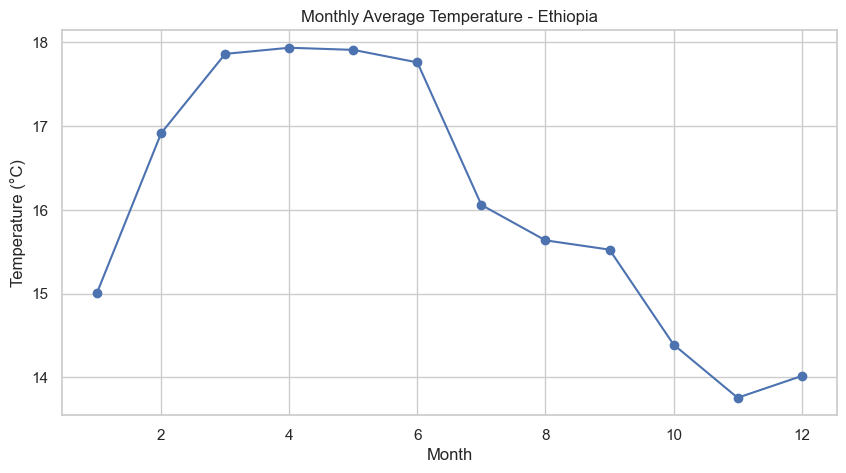

In [261]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Monthly Temperature Analysis

- Temperature remains relatively stable throughout the year.
- Slight increases and decreases indicate seasonal variation.
- Warmer months can be identified from higher average values.
- Overall, the climate appears moderate without extreme fluctuations.

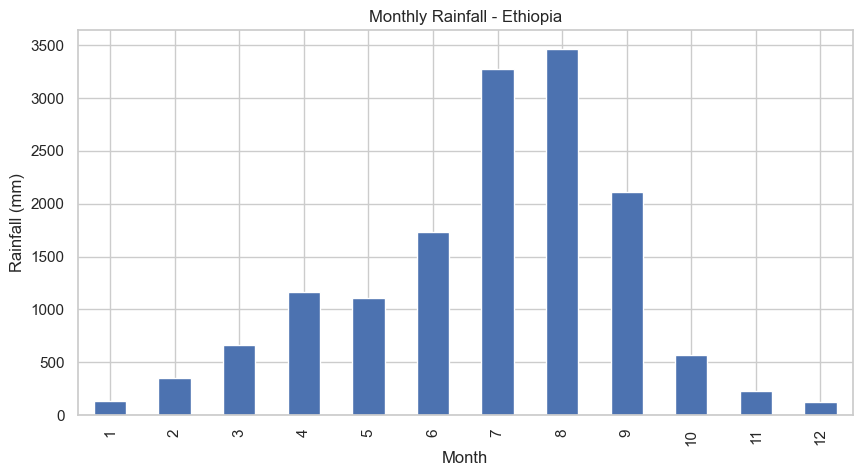

In [244]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

### Monthly Rainfall Analysis

- Rainfall varies significantly across months.
- Some months show very low rainfall, indicating dry seasons.
- Other months show high rainfall, suggesting rainy seasons.
- This pattern reflects seasonal climate behavior in Ethiopia.

In [245]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_report

,Missing Count,Missing Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


### Missing Value Percentage Analysis

- All columns show 0% missing values.
- This indicates the dataset is complete with no missing data issues.
- No further handling of missing values is required.

In [246]:
from scipy import stats

columns = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[columns]))
outliers = (z_scores > 3)

outliers.sum()

np.int64(137)

In [247]:
outlier_rows = outliers.any(axis=1)
outlier_rows.sum()

np.int64(132)

### Outlier Detection

- Outliers were identified using the Z-score method with a threshold of 3.
- A total of 137 extreme values were detected across different variables.
- These correspond to 132 rows containing unusual climate conditions.

Decision:
- Outliers are retained because they represent real-world extreme weather events such as heavy rainfall or high temperatures.
- Removing them could lead to loss of important climate insights.

In [248]:
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [249]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

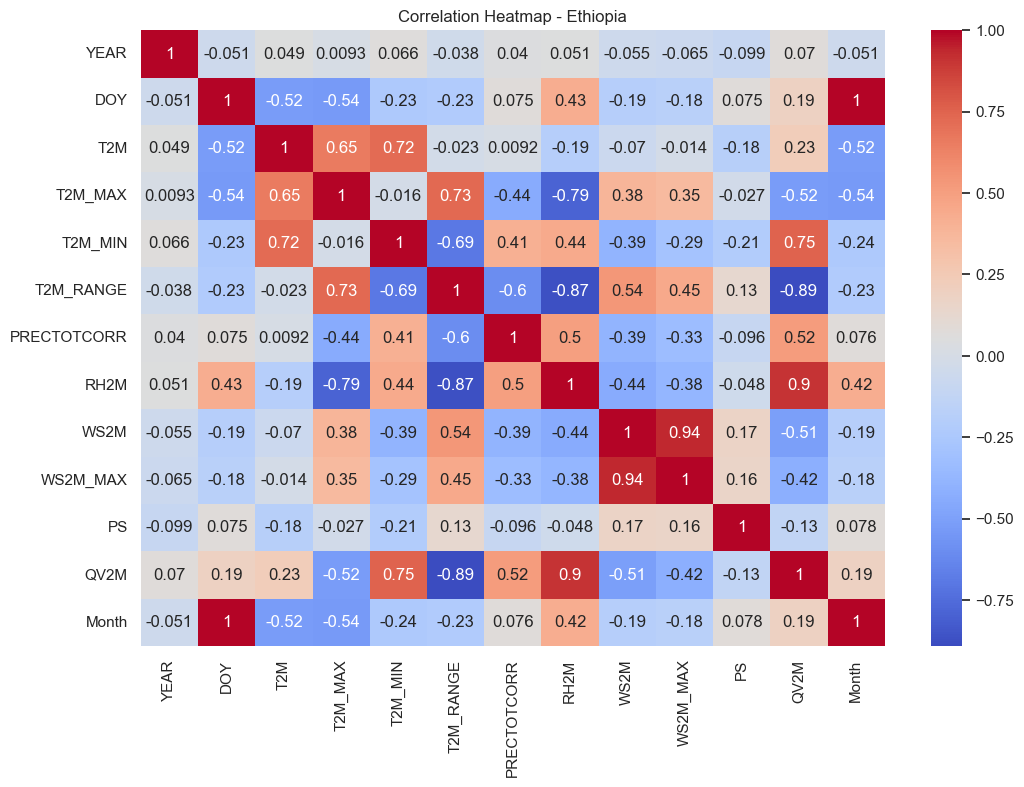

In [250]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Ethiopia")
plt.show()

### Correlation Analysis

- A very strong positive correlation (≈ 0.94) exists between WS2M and WS2M_MAX, indicating that higher average wind speeds are associated with higher maximum wind speeds.
- RH2M and QV2M show a strong positive correlation (≈ 0.90), meaning higher humidity levels correspond to higher moisture content in the air.
- A strong negative correlation (≈ -0.87) is observed between T2M_RANGE and RH2M, suggesting that higher humidity reduces temperature variation throughout the day.

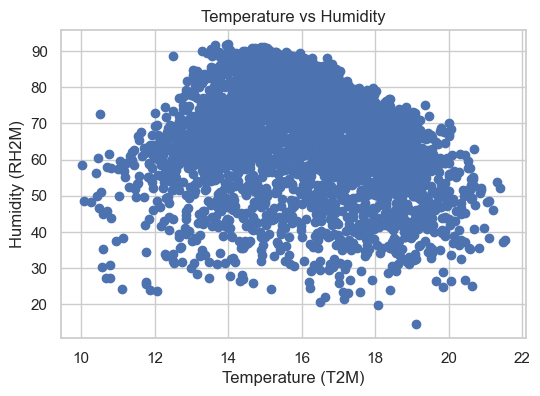

In [251]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity")
plt.show()

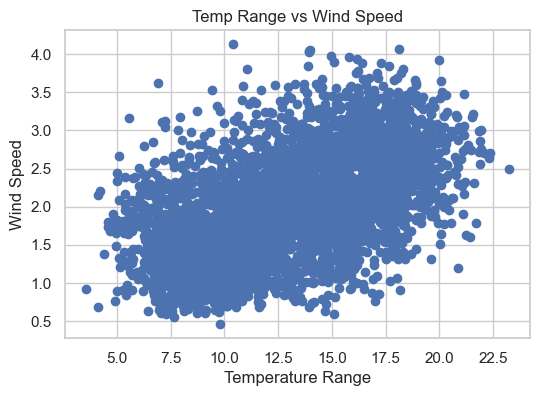

In [252]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temp Range vs Wind Speed")
plt.show()

### Scatter Plot Analysis

- Temperature and humidity show a moderate relationship, with higher temperatures often associated with lower humidity.
- Temperature range and wind speed show some variability, indicating wind does not strongly depend on temperature variation.

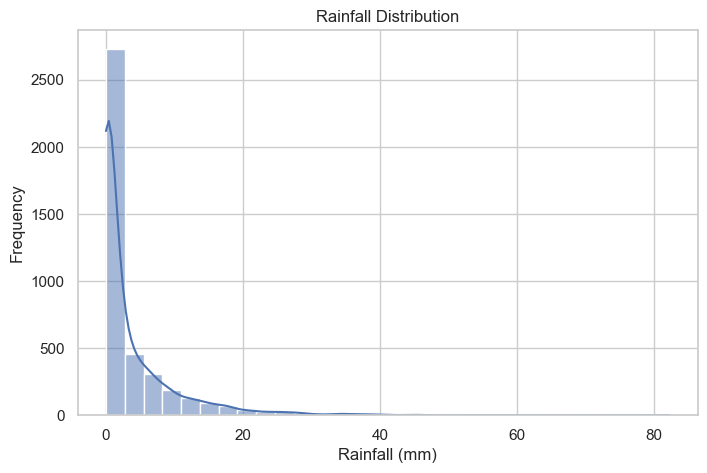

In [253]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

### Rainfall Distribution Analysis

- The rainfall distribution is highly right-skewed.
- Most days have little to no rainfall.
- A small number of days experience heavy rainfall.
- This pattern is typical for seasonal rainfall climates.

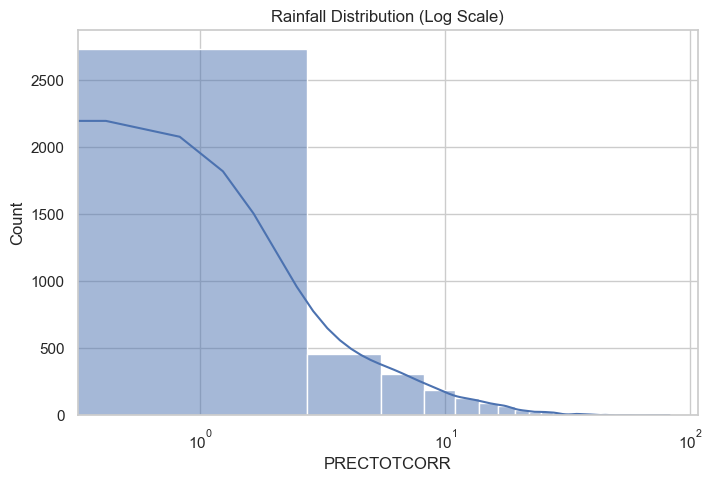

In [254]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.xscale("log")
plt.title("Rainfall Distribution (Log Scale)")
plt.show()

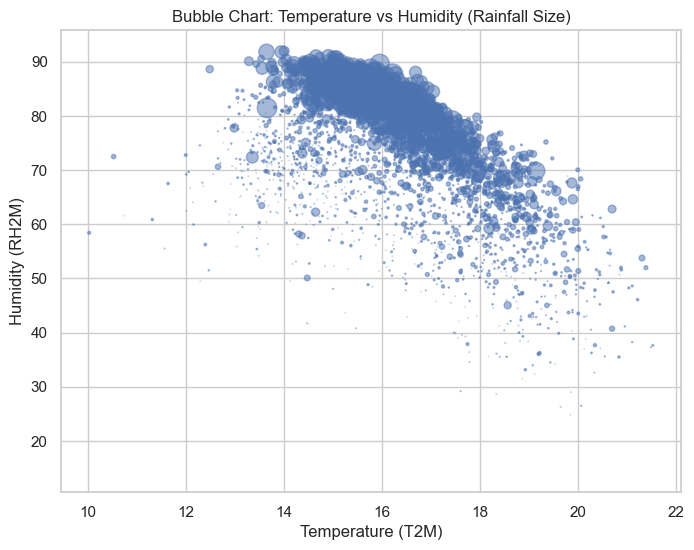

In [255]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["T2M"], 
    df["RH2M"], 
    s=df["PRECTOTCORR"] * 5,  # bubble size
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Bubble Chart: Temperature vs Humidity (Rainfall Size)")
plt.show()

### Bubble Chart Analysis

- Larger bubbles represent days with higher rainfall.
- Higher rainfall tends to occur in conditions with higher humidity.
- Temperature varies but does not strongly control rainfall size.
- This visualization highlights the interaction between temperature, humidity, and precipitation.

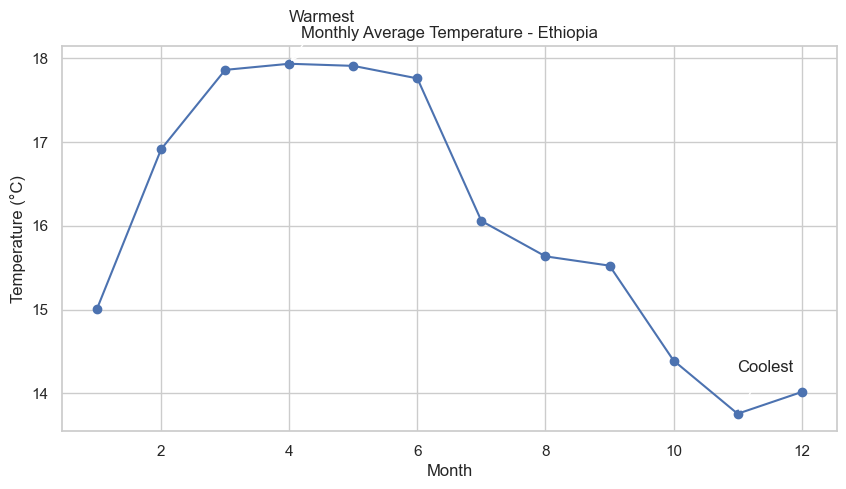

In [262]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

plt.figure(figsize=(10,5))
monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.annotate("Warmest", xy=(warmest_month, monthly_temp.max()),
             xytext=(warmest_month, monthly_temp.max()+0.5),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("Coolest", xy=(coolest_month, monthly_temp.min()),
             xytext=(coolest_month, monthly_temp.min()+0.5),
             arrowprops=dict(arrowstyle="->"))

plt.show()

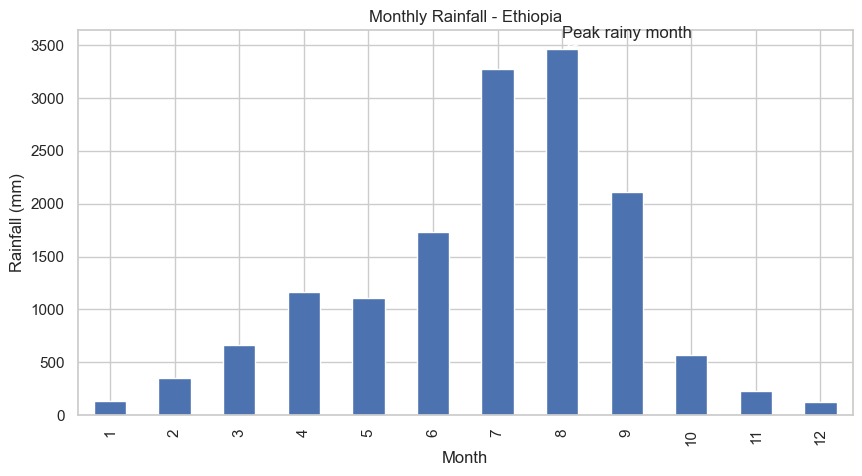

In [257]:
peak_rain_month = monthly_rain.idxmax()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

plt.annotate("Peak rainy month",
             xy=(peak_rain_month-1, monthly_rain.max()),
             xytext=(peak_rain_month-1, monthly_rain.max()+100),
             arrowprops=dict(arrowstyle="->"))

plt.show()

In [258]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

### Key Insights

- Ethiopia exhibits a moderate climate with average temperatures around 16°C.
- Rainfall is highly seasonal, with clear dry and wet periods.
- Humidity strongly correlates with moisture content and rainfall patterns.
- Extreme weather events (outliers) are present and represent real climate variability.
- Temperature variation decreases as humidity increases, indicating more stable conditions during moist periods.